# 42 — Backtest one-day Value at Risk

Forecast loss thresholds using only information available at each date and compare them with next-day HPL and APL.

VaR means Value at Risk. APL means Actual Profit and Loss. Backtesting is separate from PLA: it counts threshold exceptions and does not replace ES as the capital measure.

This step uses: Rolling 250-day P&L histories and next-day desk outcomes.

It produces: 97.5% and 99% VaR forecasts, dated exceptions and desk pass/fail results.

> Basel norm applied: MAR32 requires the forecast-at-t to outcome-at-t+1 sequence and desk tests at 97.5% and 99%.

$$Exception_{t+1}=1\{-P\&L_{t+1}>VaR_t\}$$

Synthetic inputs are labelled directly in the displayed data. Basel regulatory parameters are loaded separately from versioned configuration.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from frtb_engine.notebook_tools import INR_CRORE, configure_notebooks, crore_table, draw_flow, heatmap

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_ima_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
MANIFEST = json.loads((RUN / 'run_manifest.json').read_text(encoding='utf-8'))
STAGES = {row['stage']: ROOT / row['path'] for row in MANIFEST['artifacts']}
SUMMARY = json.loads((RUN / '27_combined_capital_summary.json').read_text(encoding='utf-8'))

def stage(name):
    return pd.read_csv(STAGES[name])

def money(value):
    return f"INR {float(value) / INR_CRORE:,.2f} crore"

print(f'IMA calculation run used: {RUN_ID}')
print('Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled')

IMA calculation run used: IMA_20260908T033903126517Z
Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled


In [2]:
detail=stage('21_backtesting_detail'); summary=stage('22_backtesting_summary'); detail['outcome_date']=pd.to_datetime(detail.outcome_date)
display(summary)
rates=summary[summary.desk=='Rates'].iloc[0]; print(f"Rates desk HPL/APL exceptions: 99% = {int(rates.hpl_exceptions_99)}/{int(rates.apl_exceptions_99)}; 97.5% = {int(rates.hpl_exceptions_97_5)}/{int(rates.apl_exceptions_97_5)}; result = {rates.backtesting_result}.")

,desk,observations,hpl_exceptions_97_5,hpl_exceptions_99,apl_exceptions_97_5,apl_exceptions_99,exceptions_used_97_5,exceptions_used_99,backtesting_result,backtesting_reason
0,Commodity,250,6,0,6,0,6,0,PASS,Exception counts are within desk thresholds
1,Credit,250,5,1,5,1,5,1,PASS,Exception counts are within desk thresholds
2,Equity,250,8,1,8,1,8,1,PASS,Exception counts are within desk thresholds
3,FX,250,7,7,7,7,7,7,PASS,Exception counts are within desk thresholds
4,Rates,250,12,8,12,8,12,8,PASS,Exception counts are within desk thresholds


Rates desk HPL/APL exceptions: 99% = 8/8; 97.5% = 12/12; result = PASS.


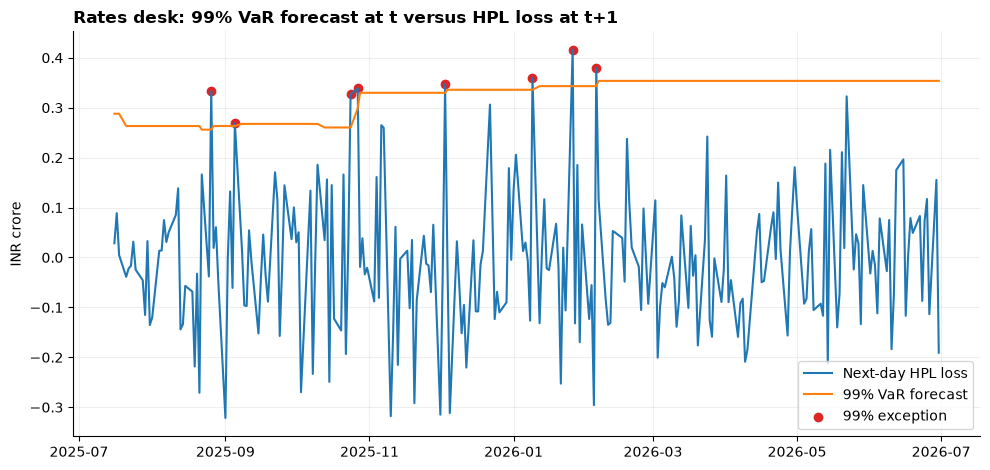

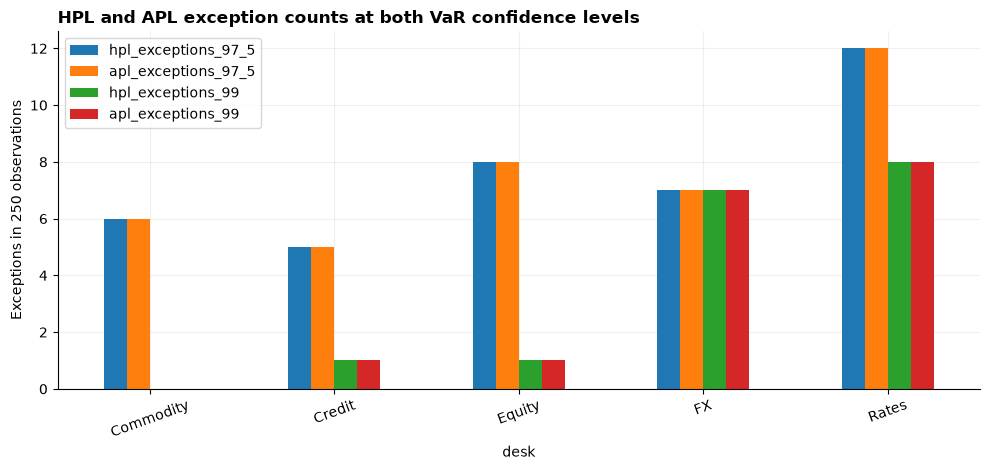

In [3]:
sample=detail[detail.desk=='Rates'].sort_values('outcome_date'); fig,ax=plt.subplots(); ax.plot(sample.outcome_date,-sample.next_day_hpl_inr/INR_CRORE,label='Next-day HPL loss'); ax.plot(sample.outcome_date,sample.var_99_inr/INR_CRORE,label='99% VaR forecast'); exc=sample[sample.hpl_exception_99]; ax.scatter(exc.outcome_date,-exc.next_day_hpl_inr/INR_CRORE,color='#DC2626',label='99% exception'); ax.set_ylabel('INR crore'); ax.set_title('Rates desk: 99% VaR forecast at t versus HPL loss at t+1',loc='left',weight='bold'); ax.legend(); plt.tight_layout(); plt.show()
exceptions=summary.set_index('desk')[['hpl_exceptions_97_5','apl_exceptions_97_5','hpl_exceptions_99','apl_exceptions_99']]; ax=exceptions.plot(kind='bar'); ax.set_ylabel('Exceptions in 250 observations'); ax.set_title('HPL and APL exception counts at both VaR confidence levels',loc='left',weight='bold'); ax.tick_params(axis='x',rotation=20); plt.tight_layout(); plt.show()

The first chart compares each Rates desk next-day loss with the 99% VaR forecast made one day earlier. Red points are dates on which realised HPL loss exceeded the forecast threshold. The second chart shows both HPL and APL exceptions at 97.5% and 99% for every desk over 250 observations.